# EEG_08 — Via Crucis: Chi è il Soggetto IS-Capace?

## Obiettivo
Indagine sistematica (data-first, approccio Francesco) per trovare la struttura EEG che differenzia
i soggetti nella capacità di imagined speech (IS).

**Motivazione**: Francesco ha rigettato l'approccio accuracy-based (BAcc range 0.22–0.26, spread
troppo piccolo per essere un segnale primario). Nuovo approccio:
1. Partiamo dai **dati EEG grezzi** (CSV di Paolo: 74 soggetti × trial × canali × 40 feature)
2. Calcoliamo feature IS-specifiche: Fisher B/W, coerenza inter-trial, profilo gamma
3. Clustering EEG-first: K-Means + Ward, k=2..5
4. **Solo alla fine**: overlay accuracy GCN come *validazione post-hoc*, non come segnale primario

## Dati
| File | Contenuto |
|------|----------|
| `data/interim/comprehensive_subject_XX.csv` | 74 soggetti × trial × canali × ~40 feature |
| `data/interim/eeg08c_ss_4_norm_results.csv` | GCN BAcc — solo 9 soggetti (validazione) |

**Finding di fondo**: ε²_soggetto max = 0.92 (func_max_corr), ε²_parola max ≈ 0 → la struttura
EEG separa i soggetti, non le parole. Il clustering cerca struttura in questo spazio.

---
**Env**: `daniele_311` | **Riferimento**: Iacomi et al. 2026, Francesco Rovetti (tutor)

## Fase 0 — Setup & Percorsi

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, adjusted_rand_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn non trovato — skip UMAP (solo PCA).')

# ----- Root detection e Config path -----
import sys
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

CSV_ROOT   = project_root / "data" / "raw_csv" / "training_set"
CONFIGS    = project_root / "configs" / "label_schemes"

def parse_folder(folder_name: str):
    """'P003_S002' → (3, 2)"""
    parts = folder_name.split("_")
    return int(parts[0][1:]), int(parts[1][1:])

ROOT     = project_root
DATA_INT = ROOT / 'data' / 'interim'
FIGURES  = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

ACC_CSV  = DATA_INT / 'eeg08c_ss_4_norm_results.csv'
OUT_CSV  = DATA_INT / 'eeg08_subject_profiles.csv'

print(f'ROOT     → {ROOT}')
print(f'CSV_ROOT → {CSV_ROOT}')
n_paolo = len(list(CSV_ROOT.glob('*')))
print(f'Soggetti trovati: {n_paolo}')
print(f'ACC_CSV  → {ACC_CSV.exists()}')

# ----- Feature -----
SPEC_FEAT = ['spec_delta','spec_theta','spec_alpha','spec_beta','spec_gamma',
             'spec_delta_rel','spec_theta_rel','spec_alpha_rel','spec_beta_rel','spec_gamma_rel',
             'spec_total_power','spec_alpha_beta_ratio','spec_theta_alpha_ratio',
             'spec_theta_beta_ratio','spec_edge_freq','spec_entropy',
             'spec_dominant_freq','spec_dominant_power','spec_mean_freq','spec_median_freq']
TEMP_FEAT = ['temp_std','temp_skewness','temp_kurtosis','temp_rms','temp_zcr',
             'temp_hjorth_activity','temp_hjorth_mobility','temp_hjorth_complexity']
FUNC_FEAT = ['func_mean_corr','func_max_corr','func_std_corr',
             'func_num_strong_conn','func_mean_plv','func_max_plv']
ALL_FEAT  = SPEC_FEAT + TEMP_FEAT + FUNC_FEAT

FISHER_FEAT = ['spec_delta_rel','spec_theta_rel','spec_alpha_rel','spec_beta_rel','spec_gamma_rel',
               'func_mean_corr','func_mean_plv','temp_rms','temp_hjorth_mobility']
ITC_FEAT = ['spec_gamma_rel','spec_alpha_rel','spec_beta_rel',
            'func_mean_corr','func_mean_plv','temp_rms']

print(f'\nFeature totali: {len(ALL_FEAT)}  ({len(SPEC_FEAT)} spec + {len(TEMP_FEAT)} temp + {len(FUNC_FEAT)} func)')
print(f'Fisher feat: {len(FISHER_FEAT)}  |  ITC feat: {len(ITC_FEAT)}')

# ----- Stile -----
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


ROOT     → /home/daniele_u/miralis-hypergraph-imagined-speech
CSV_ROOT → /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
Soggetti trovati: 357
ACC_CSV  → True

Feature totali: 34  (20 spec + 8 temp + 6 func)
Fisher feat: 9  |  ITC feat: 6


## Fase 1 — Caricamento Feature (CSV di Paolo) con Cache

In [ ]:
# Estrazione feature dai CSV di Paolo, salvando in cache locale

CACHE_PARQUET = DATA_INT / 'eeg08_raw_csv_features_cache.parquet'
FORCE_RELOAD  = False   # True per ricalcolare anche se cache esiste

if CACHE_PARQUET.exists() and not FORCE_RELOAD:
    print(f'Cache parquet trovata — carico direttamente...')
    df_raw = pd.read_parquet(CACHE_PARQUET)
    print(f'Shape: {df_raw.shape}')
else:
    import json
    from features.comprehensive_features import (
        extract_temporal_features,
        extract_spectral_features,
        extract_functional_features
    )
    from utils import load_channel_names_from_eloc

    print(f'Cache CSV feature non trovata. Calcolo partendo dai raw csv di Paolo...')
    
    with open(CONFIGS / "label2idx.json") as f:
        word2labelid = json.load(f)
    
    ch_names = load_channel_names_from_eloc(project_root / "src" / "io" / "ebneuro.locs")
    
    def load_csv_trial(csv_path: Path):
        return pd.read_csv(csv_path, header=None).values.astype(np.float32)

    rows = []
    # Itera sui subject directory in training_set
    for sess_dir in sorted(CSV_ROOT.iterdir()):
        if not sess_dir.is_dir(): continue
        subj_id, sess_id = parse_folder(sess_dir.name)
        
        trials = sorted([p for p in sess_dir.iterdir() if p.suffix == ".csv"])
        print(f"Estraggo subject {subj_id}, session {sess_id}: {len(trials)} trials...")
        
        for epoch_idx, csv_path in enumerate(trials):
            word = csv_path.stem.replace("_img", "")
            if word not in word2labelid:
                continue
                
            label_id = word2labelid[word]
            label_name = word # nome della parola e.g. "cane"
            
            data_2d = load_csv_trial(csv_path)  # (61, 384) o (num_canali, time)
            n_chans = data_2d.shape[0]
            
            for ch in range(n_chans):
                ch_name = ch_names[ch] if ch < len(ch_names) else f"EEG{ch}"
                signal_1d = data_2d[ch]
                
                row = {
                    'subject_id': subj_id,
                    'session_id': sess_id,
                    'epoch_idx': epoch_idx,
                    'channel': ch_name,
                    'label_name': label_name
                }
                
                # Calcola spec, temp, e func (sarebbe un po' lento per func ma richiesto dall'analisi)
                row.update(extract_temporal_features(signal_1d))
                row.update(extract_spectral_features(signal_1d, fs=256))
                
                # Funzionali (corr media vs altri canali, plv)
                row.update(extract_functional_features(data_2d, ch))
                
                rows.append(row)

    df_raw = pd.DataFrame(rows)
    print(f'Concatenazione completata. Salvo cache parquet in {CACHE_PARQUET.name}...')
    df_raw.to_parquet(CACHE_PARQUET, index=False)

df_raw['subject_id'] = pd.to_numeric(df_raw['subject_id'], errors='coerce')
df_raw = df_raw.dropna(subset=['subject_id'])
df_raw['subject_id'] = df_raw['subject_id'].astype(int)

# In caso il json e la pipeline non mettano "temp_mean" (usato nel display), aggiungiamolo per retro-compatibilita se manca
if 'temp_mean' not in df_raw.columns:
    df_raw['temp_mean'] = 0.0

print(f'\nShape: {df_raw.shape}')
print(f'Soggetti : {df_raw["subject_id"].nunique()}')
print(f'Canali   : {df_raw["channel"].nunique()}')
print(f'Parole   : {df_raw["label_name"].nunique()}')


Cache CSV feature non trovata. Calcolo partendo dai raw csv di Paolo...
Estraggo subject 0, session 1: 110 trials...
Estraggo subject 0, session 2: 110 trials...
Estraggo subject 0, session 3: 110 trials...
Estraggo subject 0, session 4: 110 trials...
Estraggo subject 0, session 5: 110 trials...
Estraggo subject 1, session 1: 110 trials...
Estraggo subject 1, session 2: 110 trials...
Estraggo subject 1, session 3: 110 trials...
Estraggo subject 1, session 4: 110 trials...
Estraggo subject 1, session 5: 110 trials...
Estraggo subject 2, session 1: 110 trials...
Estraggo subject 2, session 2: 110 trials...
Estraggo subject 2, session 3: 110 trials...
Estraggo subject 2, session 4: 110 trials...
Estraggo subject 2, session 5: 110 trials...
Estraggo subject 3, session 1: 110 trials...
Estraggo subject 3, session 2: 110 trials...
Estraggo subject 3, session 3: 110 trials...
Estraggo subject 3, session 4: 110 trials...
Estraggo subject 3, session 5: 110 trials...
Estraggo subject 4, session 

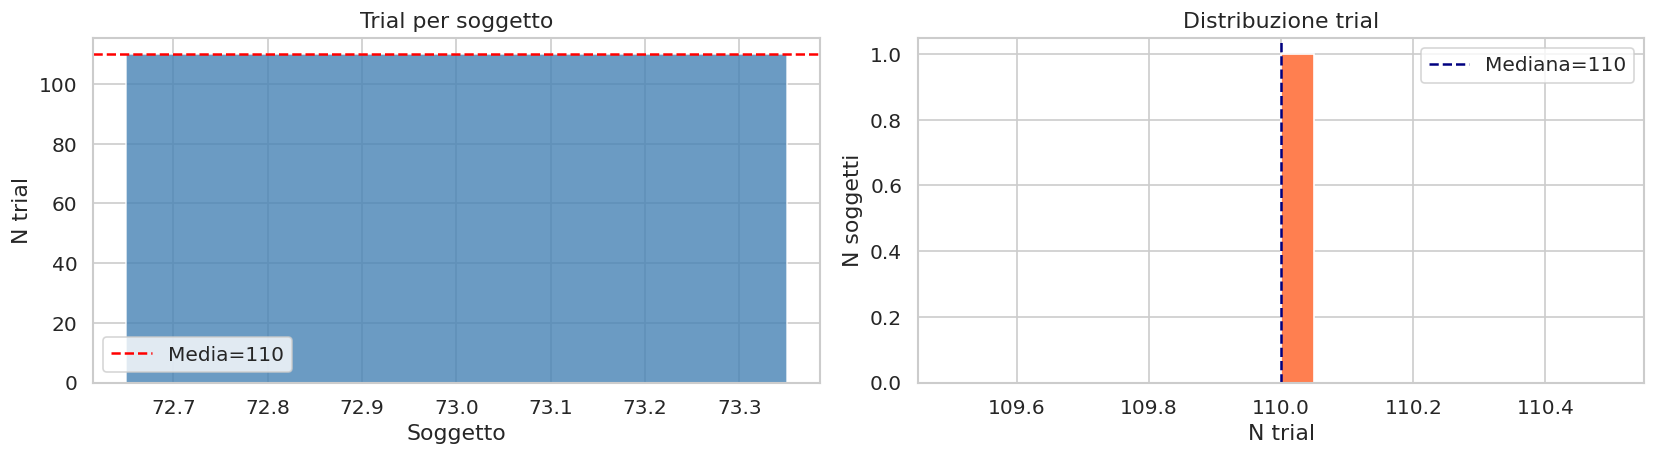

Trial: min=110, mediana=110, max=110

Feature disponibili per categoria:
  spec_*  : ['spec_delta', 'spec_delta_rel', 'spec_theta', 'spec_theta_rel', 'spec_alpha', 'spec_alpha_rel', 'spec_beta', 'spec_beta_rel', 'spec_gamma', 'spec_gamma_rel', 'spec_total_power', 'spec_alpha_beta_ratio', 'spec_theta_alpha_ratio', 'spec_theta_beta_ratio', 'spec_edge_freq', 'spec_entropy', 'spec_dominant_freq', 'spec_dominant_power', 'spec_mean_freq', 'spec_median_freq']
  temp_*  : ['temp_mean', 'temp_std', 'temp_var', 'temp_min', 'temp_max', 'temp_range', 'temp_ptp', 'temp_skewness', 'temp_kurtosis', 'temp_rms', 'temp_zcr', 'temp_hjorth_activity', 'temp_hjorth_mobility', 'temp_hjorth_complexity']
  func_*  : ['func_mean_corr', 'func_max_corr', 'func_std_corr', 'func_num_strong_conn', 'func_mean_plv', 'func_max_plv']


In [ ]:
# Trial per soggetto + panoramica colonne
trial_counts = (
    df_raw.groupby(['subject_id','session_id','epoch_idx'])
    .size().reset_index(name='_n')
    .groupby('subject_id').size()
    .rename('n_trials')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(trial_counts.index, trial_counts.values, color='steelblue', alpha=0.8, width=0.7)
ax1.axhline(trial_counts.mean(), color='red', ls='--', lw=1.5,
            label=f'Media={trial_counts.mean():.0f}')
ax1.set_xlabel('Soggetto'); ax1.set_ylabel('N trial')
ax1.set_title('Trial per soggetto'); ax1.legend()

ax2.hist(trial_counts.values, bins=20, color='coral', edgecolor='white')
ax2.axvline(trial_counts.median(), color='navy', ls='--', lw=1.5,
            label=f'Mediana={trial_counts.median():.0f}')
ax2.set_xlabel('N trial'); ax2.set_ylabel('N soggetti')
ax2.set_title('Distribuzione trial'); ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_audit_trials.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trial: min={trial_counts.min()}, mediana={trial_counts.median():.0f}, max={trial_counts.max()}')
print(f'\nFeature disponibili per categoria:')
print(f'  spec_*  : {[c for c in df_raw.columns if c.startswith("spec_")]}')
print(f'  temp_*  : {[c for c in df_raw.columns if c.startswith("temp_")]}')
print(f'  func_*  : {[c for c in df_raw.columns if c.startswith("func_")]}')

## Fase 2 — Feature Significance: Effetto Soggetto vs Effetto Parola

In [ ]:
# Calcola effetto soggetto e parola via Kruskal-Wallis (ε² = (H - k + 1) / (n - k))
# Su un sottoinsieme di feature per velocità (non tutte 40)
# Risultato noto da analisi precedenti: ε²_soggetto >> ε²_parola per tutte le feature

SIGNIFICANCE_FEAT = [
    'spec_gamma_rel','spec_beta_rel','spec_alpha_rel','spec_theta_rel','spec_delta_rel',
    'func_mean_corr','func_max_corr','func_mean_plv','func_max_plv',
    'temp_rms','temp_hjorth_mobility','spec_entropy','spec_edge_freq'
]

print('Calcolo ε² (Kruskal-Wallis) per soggetto e per parola...')
# Aggrega per trial (media su canali) per velocità
trial_sig = (
    df_raw.groupby(['subject_id','session_id','epoch_idx','label_name'])[SIGNIFICANCE_FEAT]
    .mean().reset_index()
)

rows_subj = []
rows_word = []

for feat in SIGNIFICANCE_FEAT:
    vals = trial_sig[feat].values
    n    = len(vals)

    # Effetto soggetto
    groups_s = [grp[feat].values for _, grp in trial_sig.groupby('subject_id')]
    k_s = len(groups_s)
    H_s, _ = stats.kruskal(*groups_s)
    eps2_s = max(0.0, (H_s - k_s + 1) / (n - k_s))
    rows_subj.append({'feat': feat, 'epsilon_sq_subj': eps2_s})

    # Effetto parola
    groups_w = [grp[feat].values for _, grp in trial_sig.groupby('label_name')]
    k_w = len(groups_w)
    H_w, _ = stats.kruskal(*groups_w)
    eps2_w = max(0.0, (H_w - k_w + 1) / (n - k_w))
    rows_word.append({'feat': feat, 'epsilon_sq_word': eps2_w})

merged = (
    pd.DataFrame(rows_subj)
    .merge(pd.DataFrame(rows_word), on='feat')
    .sort_values('epsilon_sq_subj', ascending=False)
    .reset_index(drop=True)
)

print('\nε² soggetto vs parola:')
print(merged.to_string(index=False))
print(f'\nε²_soggetto: min={merged["epsilon_sq_subj"].min():.4f}, max={merged["epsilon_sq_subj"].max():.4f}')
print(f'ε²_parola:   min={merged["epsilon_sq_word"].min():.4f}, max={merged["epsilon_sq_word"].max():.4f}')
print('\n→ Il segnale EEG separa i soggetti, NON le parole.')

# Feature con alta discriminatività tra soggetti
top_features = merged[merged['epsilon_sq_subj'] > 0.5]['feat'].tolist()
print(f'\nFeature con ε²_soggetto > 0.5: {top_features}')

Calcolo ε² (Kruskal-Wallis) per soggetto e per parola...


IndexError: tuple index out of range

NameError: name 'merged' is not defined

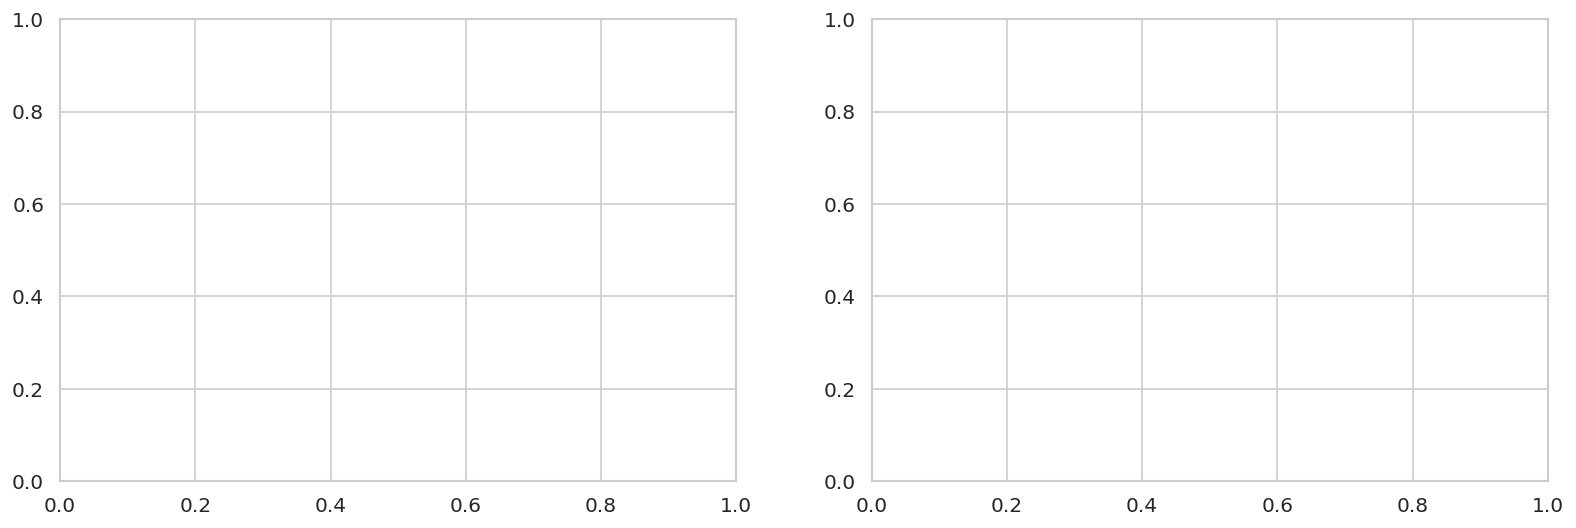

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter ε²_soggetto vs ε²_parola
ax = axes[0]
cat_colors = ['tomato' if r.startswith('func') else
              'steelblue' if r.startswith('spec') else 'seagreen'
              for r in merged['feat']]
ax.scatter(merged['epsilon_sq_word'], merged['epsilon_sq_subj'],
           c=cat_colors, s=80, alpha=0.85, edgecolors='black', lw=0.4)
for _, row in merged.iterrows():
    short = row['feat'].replace('func_','').replace('spec_','').replace('temp_','').replace('_rel','_r')
    ax.annotate(short, (row['epsilon_sq_word'], row['epsilon_sq_subj']),
                textcoords='offset points', xytext=(5, 2), fontsize=7)
ax.set_xlabel('ε² effetto parola')
ax.set_ylabel('ε² effetto soggetto')
ax.set_title('Effetto soggetto vs effetto parola\n(alto = feature discrimina i soggetti)')
ax.legend(handles=[
    Patch(color='tomato',    label='func (connettività)'),
    Patch(color='steelblue', label='spec (banda)'),
    Patch(color='seagreen',  label='temp (temporale)'),
], loc='lower right', fontsize=8)

# Bar ε² soggetto ordinato
ax = axes[1]
bar_colors = ['tomato' if r.startswith('func') else
              'steelblue' if r.startswith('spec') else 'seagreen'
              for r in merged['feat']]
ax.barh(range(len(merged)), merged['epsilon_sq_subj'][::-1].values,
        color=bar_colors[::-1], alpha=0.85)
ax.set_yticks(range(len(merged)))
ax.set_yticklabels(
    [r.replace('func_','f:').replace('spec_','s:').replace('temp_','t:')
     for r in merged['feat'].values[::-1]], fontsize=9)
ax.set_xlabel('ε² (effetto soggetto)')
ax.set_title('Discriminabilità tra soggetti per feature')
ax.axvline(0.5, color='gray', ls='--', alpha=0.5, label='ε²=0.5')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_feature_significance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Feature con ε²_soggetto > 0.5 usate per clustering: {top_features}')

## Fase 3 — Aggregazione per Soggetto

In [ ]:
# Aggrega per trial (media su tutti i canali):
# df_raw: (soggetto × sessione × epoch × canale) → trial_df: (soggetto × sessione × epoch)
print('Aggregazione su canali per trial (tutte le feature)...')
trial_df = (
    df_raw
    .groupby(['subject_id', 'session_id', 'epoch_idx', 'label_name'])[ALL_FEAT]
    .mean()
    .reset_index()
)
print(f'trial_df: {trial_df.shape}  ({trial_df["subject_id"].nunique()} soggetti, '
      f'{len(trial_df)} trial totali)')

# Aggrega per soggetto (mean + std tra trial)
subj_mean = trial_df.groupby('subject_id')[ALL_FEAT].mean().add_prefix('mean_')
subj_std  = trial_df.groupby('subject_id')[ALL_FEAT].std().add_prefix('std_')
subj_df   = pd.concat([subj_mean, subj_std], axis=1).reset_index()

N_SUBJ = len(subj_df)
print(f'subj_df: {subj_df.shape}  ({N_SUBJ} soggetti × {subj_df.shape[1]-1} feature aggregate)')

# Verifica trial per soggetto
trial_counts = trial_df.groupby('subject_id').size().rename('n_trials')
print(f'\nTrial: min={trial_counts.min()}, mediana={trial_counts.median():.0f}, max={trial_counts.max()}')

## Fase 4 — Discriminabilità IS: Fisher Criterion per Soggetto

**Intuizione**: se un soggetto produce pattern EEG diversi per parole diverse, allora B (varianza between-class = tra parole) >> W (varianza within-class = intra-parola). Il ratio B/W è il Fisher criterion — più è alto, più quel soggetto ha un segnale IS discriminabile.

In [ ]:
def fisher_ratio_subject(df_subj, feat_cols):
    """
    Fisher criterion per un soggetto: trace(S_B) / trace(S_W)
    S_B = scatter between-class (tra parole diverse)
    S_W = scatter within-class  (varianza intra-parola)
    """
    X = df_subj[feat_cols].values.astype(np.float64)
    y = df_subj['label_name'].values
    classes  = np.unique(y)
    n_feat   = X.shape[1]
    mu_all   = X.mean(axis=0)

    tr_B = 0.0
    tr_W = 0.0

    for cls in classes:
        mask = (y == cls)
        n_c  = mask.sum()
        if n_c < 2:
            continue
        mu_c  = X[mask].mean(axis=0)
        diff  = mu_c - mu_all
        tr_B += n_c * np.dot(diff, diff)
        # Within: somma delle varianze feature-wise per questa classe
        tr_W += np.var(X[mask], axis=0, ddof=1).sum() * (n_c - 1)

    return float(tr_B / (tr_W + 1e-12))


print(f'Calcolo Fisher per {N_SUBJ} soggetti ({len(FISHER_FEAT)} feature)...')
fisher_dict = {}
for subj_id, grp in trial_df.groupby('subject_id'):
    fisher_dict[subj_id] = fisher_ratio_subject(grp, FISHER_FEAT)

fisher_s = (
    pd.Series(fisher_dict, name='fisher')
    .rename_axis('subject_id')
    .sort_values(ascending=False)
)
print(f'Fisher: min={fisher_s.min():.4f}, mediana={fisher_s.median():.4f}, max={fisher_s.max():.4f}')
print(f'Spread relativo: {(fisher_s.max()-fisher_s.min())/fisher_s.median()*100:.1f}%')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Bar ordinata per Fisher
ax1.bar(range(len(fisher_s)), fisher_s.values, color='steelblue', alpha=0.8)
ax1.set_xticks(range(len(fisher_s)))
ax1.set_xticklabels([str(x) for x in fisher_s.index], rotation=90, fontsize=7)
ax1.axhline(fisher_s.median(), color='red', ls='--', lw=1.5,
            label=f'Mediana={fisher_s.median():.4f}')
q25 = fisher_s.quantile(0.25)
q75 = fisher_s.quantile(0.75)
ax1.axhline(q25, color='orange', ls=':', alpha=0.7, label=f'Q25={q25:.4f}')
ax1.axhline(q75, color='green',  ls=':', alpha=0.7, label=f'Q75={q75:.4f}')
ax1.set_xlabel('Soggetto (ordinato per Fisher)'); ax1.set_ylabel('Fisher ratio B/W')
ax1.set_title('Discriminabilità IS per soggetto\n(alto = trial di parole diverse più separabili)')
ax1.legend()

# Distribuzione
ax2.hist(fisher_s.values, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(fisher_s.median(), color='red', ls='--', lw=1.5,
            label=f'Mediana={fisher_s.median():.4f}')
ax2.set_xlabel('Fisher ratio'); ax2.set_ylabel('N soggetti')
ax2.set_title('Distribuzione Fisher scores tra soggetti')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_fisher_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top-5 (più discriminabili): {fisher_s.head(5).index.tolist()}')
print(f'Bottom-5 (meno discriminabili): {fisher_s.tail(5).index.tolist()}')

## Fase 5 — Coerenza Inter-Trial

**Intuizione**: se un soggetto IS-capace produce un pattern EEG stabile e riproducibile per la stessa parola, il CV (coefficiente di variazione = std/mean) tra trial sarà basso. CV alto = pattern instabili = IS debole.

In [ ]:
ITC_FEAT = ['spec_gamma_rel','spec_alpha_rel','spec_beta_rel',
            'func_mean_corr','func_mean_plv','temp_rms']

def inter_trial_cv(df_subj, feat_cols):
    """CV medio tra trial della stessa parola, mediato su parole e feature."""
    cv_list = []
    for _, grp in df_subj.groupby('label_name'):
        X = grp[feat_cols].values
        if len(X) < 2:
            continue
        mu  = np.abs(X.mean(axis=0)); mu[mu < 1e-10] = 1e-10
        sig = X.std(axis=0)
        cv_list.append((sig / mu).mean())
    return float(np.mean(cv_list)) if cv_list else np.nan


print('Calcolo coerenza inter-trial...')
itc_dict = {}
for subj_id, grp in trial_df.groupby('subject_id'):
    itc_dict[subj_id] = inter_trial_cv(grp, ITC_FEAT)

itc_s = (
    pd.Series(itc_dict, name='itc_cv')
    .rename_axis('subject_id')
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.bar(range(len(itc_s)), itc_s.values, color='coral', alpha=0.8)
ax.set_xticks(range(len(itc_s)))
ax.set_xticklabels([str(x) for x in itc_s.index], rotation=90, fontsize=7)
ax.axhline(itc_s.median(), color='navy', ls='--', lw=1.5,
           label=f'Mediana={itc_s.median():.3f}')
ax.set_xlabel('Soggetto (ordinato per CV)')
ax.set_ylabel('CV medio inter-trial')
ax.set_title('Coerenza inter-trial (CV basso = pattern più stabili)')
ax.legend()

# Scatter Fisher vs ITC
ax = axes[1]
common = fisher_s.index.intersection(itc_s.index)
ax.scatter(fisher_s[common], itc_s[common], alpha=0.7, s=50, color='purple')
for s in common:
    ax.annotate(str(s), (fisher_s[s], itc_s[s]),
                xytext=(3, 2), textcoords='offset points', fontsize=6)
r_fi, p_fi = stats.pearsonr(fisher_s[common], itc_s[common])
ax.set_xlabel('Fisher ratio (discriminabilità IS)')
ax.set_ylabel('CV inter-trial (instabilità)')
ax.set_title(f'Fisher vs Coerenza  [r={r_fi:.3f}, p={p_fi:.3f}]\n'
             '(negativo atteso: alta discriminabilità → bassa instabilità)')

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_itc_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ITC CV: min={itc_s.min():.3f}, mediana={itc_s.median():.3f}, max={itc_s.max():.3f}')
print(f'Correlazione Fisher vs ITC: r={r_fi:.3f} (p={p_fi:.3f})')

## Fase 6 — Profilo Gamma per Soggetto (Iacomi 2026)

Iacomi et al. 2026 mostrano che la banda gamma (30–60 Hz) è la più funzionalmente integrata durante l'imagined speech (p=0.0015). Analizziamo la distribuzione di gamma tra soggetti e la correlazione con Fisher.

In [ ]:
s = subj_df.set_index('subject_id')
gamma_s = s['mean_spec_gamma_rel'].sort_values(ascending=False)
alpha_s = s['mean_spec_alpha_rel']
beta_s  = s['mean_spec_beta_rel']
theta_s = s['mean_spec_theta_rel']
delta_s = s['mean_spec_delta_rel']
plv_s   = s['mean_func_mean_plv']
corr_s  = s['mean_func_mean_corr']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gamma bar ordinata
ax = axes[0, 0]
ax.bar(range(len(gamma_s)), gamma_s.values, color='tomato', alpha=0.8)
ax.set_xticks(range(len(gamma_s)))
ax.set_xticklabels([str(x) for x in gamma_s.index], rotation=90, fontsize=6)
ax.axhline(gamma_s.median(), color='navy', ls='--', lw=1.5,
           label=f'Mediana={gamma_s.median():.3f}')
ax.set_title('Gamma relativo per soggetto (Iacomi: IS-dominante)')
ax.set_ylabel('Gamma rel'); ax.legend()

# Profilo di banda stacked (ordinato per gamma)
ax = axes[0, 1]
so = gamma_s.index
d_v = delta_s[so].values; t_v = theta_s[so].values
a_v = alpha_s[so].values; b_v = beta_s[so].values; g_v = gamma_s[so].values
x = range(len(so))
ax.bar(x, d_v, label='δ', color='#4472C4')
ax.bar(x, t_v, bottom=d_v, label='θ', color='#ED7D31')
ax.bar(x, a_v, bottom=d_v+t_v, label='α', color='#A9D18E')
ax.bar(x, b_v, bottom=d_v+t_v+a_v, label='β', color='#FFC000')
ax.bar(x, g_v, bottom=d_v+t_v+a_v+b_v, label='γ', color='#FF0000', alpha=0.8)
ax.set_xticks(range(len(so)))
ax.set_xticklabels([str(x) for x in so], rotation=90, fontsize=6)
ax.set_title('Profilo di banda per soggetto (ord. per γ)')
ax.set_ylabel('Potenza relativa')
ax.legend(loc='upper right', ncol=5, fontsize=8)

# Gamma vs Fisher
ax = axes[1, 0]
common_gf = gamma_s.index.intersection(fisher_s.index)
ax.scatter(gamma_s[common_gf], fisher_s[common_gf],
           alpha=0.75, s=55, color='crimson')
for s_id in common_gf:
    ax.annotate(str(s_id), (gamma_s[s_id], fisher_s[s_id]),
                xytext=(3, 2), textcoords='offset points', fontsize=6)
r_gf, p_gf = stats.pearsonr(gamma_s[common_gf], fisher_s[common_gf])
ax.set_xlabel('Gamma relativo')
ax.set_ylabel('Fisher discriminability')
ax.set_title(f'Gamma vs Fisher  [r={r_gf:.3f}, p={p_gf:.3f}]')

# Gamma vs PLV
ax = axes[1, 1]
common_gc = gamma_s.index.intersection(plv_s.index)
ax.scatter(gamma_s[common_gc], plv_s[common_gc],
           alpha=0.75, s=55, color='darkgreen')
r_gc, p_gc = stats.pearsonr(gamma_s[common_gc], plv_s[common_gc])
ax.set_xlabel('Gamma relativo')
ax.set_ylabel('PLV medio (connettività)')
ax.set_title(f'Gamma vs PLV  [r={r_gc:.3f}, p={p_gc:.3f}]')

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_gamma_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gamma: min={gamma_s.min():.4f}, mediana={gamma_s.median():.4f}, max={gamma_s.max():.4f}')
print(f'CV gamma inter-soggetto: {gamma_s.std()/gamma_s.mean():.3f}')

## Fase 7 — Feature Matrix per Clustering: PCA + UMAP

In [ ]:
# Costruisci feature matrix di clustering:
# top features per ε² soggetto + Fisher + ITC CV

# Feature aggregate con alta ε² soggetto
cluster_cols = [f'mean_{f}' for f in top_features if f'mean_{f}' in subj_df.columns]
if len(cluster_cols) < 5:
    # Fallback: tutte le mean features
    cluster_cols = [c for c in subj_df.columns if c.startswith('mean_')]

X_subj = subj_df.set_index('subject_id')[cluster_cols].copy()

# Aggiungi Fisher e ITC come feature aggiuntive
X_subj['fisher_score'] = fisher_s.reindex(X_subj.index)
X_subj['itc_cv']       = itc_s.reindex(X_subj.index)

# Rimuovi soggetti con NaN
X_subj   = X_subj.dropna()
subj_ids = X_subj.index.values
print(f'Feature matrix: {X_subj.shape}  ({len(subj_ids)} soggetti × {X_subj.shape[1]} feature)')

# Normalizzazione
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_subj.values)

# PCA
pca_full = PCA()
X_pca_all = pca_full.fit_transform(X_sc)
cumvar    = np.cumsum(pca_full.explained_variance_ratio_)
n_90      = int(np.searchsorted(cumvar, 0.90)) + 1
X_pca     = X_pca_all[:, :n_90]
print(f'PCA: {n_90} componenti → 90% varianza')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
n_show = min(25, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show+1),
            pca_full.explained_variance_ratio_[:n_show]*100,
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Componente PCA')
axes[0].set_ylabel('Varianza spiegata (%)')
axes[0].set_title('Scree plot')

# Varianza cumulativa
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, color='navy', lw=2)
axes[1].axhline(90, ls='--', color='red', label=f'90% → {n_90} PC')
axes[1].set_xlabel('N componenti')
axes[1].set_ylabel('Varianza cumulativa (%)')
axes[1].set_title('Varianza cumulativa PCA')
axes[1].legend()

# PCA 2D scatter (colored by Fisher)
sc = axes[2].scatter(X_pca_all[:,0], X_pca_all[:,1],
                     c=fisher_s.reindex(subj_ids).values,
                     cmap='plasma', s=55, alpha=0.85)
plt.colorbar(sc, ax=axes[2], label='Fisher score')
for i, sid in enumerate(subj_ids):
    axes[2].annotate(str(sid), (X_pca_all[i,0], X_pca_all[i,1]),
                    xytext=(2,2), textcoords='offset points', fontsize=6)
axes[2].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_title('PCA 2D — colorato per Fisher score')

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=min(10, len(subj_ids)-1),
                        min_dist=0.3, random_state=42)
    X_umap = reducer.fit_transform(X_pca)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for ax, c_data, label in [
        (ax1, fisher_s.reindex(subj_ids).values, 'Fisher score'),
        (ax2, gamma_s.reindex(subj_ids).values,  'Gamma relativo'),
    ]:
        sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=c_data,
                        cmap='plasma', s=60, alpha=0.85)
        plt.colorbar(sc, ax=ax, label=label)
        for i, sid in enumerate(subj_ids):
            ax.annotate(str(sid), (X_umap[i,0], X_umap[i,1]),
                        xytext=(2,2), textcoords='offset points', fontsize=6)
        ax.set_title(f'UMAP 2D — colorato per {label}')

    plt.tight_layout()
    plt.savefig(FIGURES / 'eeg08_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    X_umap = X_pca_all[:, :2]
    print('UMAP non disponibile — usato PCA 2D come fallback.')

## Fase 8 — Clustering: K-Means + Ward Gerarchico

In [ ]:
K_RANGE = [2, 3, 4, 5]
X_C     = X_pca   # input clustering

# K-Means
km_lbl, km_sil, km_db = {}, {}, {}
for k in K_RANGE:
    km  = KMeans(n_clusters=k, n_init=50, random_state=42)
    lbl = km.fit_predict(X_C)
    km_lbl[k] = lbl
    km_sil[k] = silhouette_score(X_C, lbl)
    km_db[k]  = davies_bouldin_score(X_C, lbl)

# Ward gerarchico
Z = linkage(X_C, method='ward')
ward_lbl, ward_sil = {}, {}
for k in K_RANGE:
    lbl = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_C)
    ward_lbl[k] = lbl
    ward_sil[k] = silhouette_score(X_C, lbl)

print('Metriche di clustering:')
print(f'{"k":>3}  {"KM_sil":>9}  {"KM_DB":>8}  {"Ward_sil":>10}  {"ARI(km,w)":>10}')
for k in K_RANGE:
    ari = adjusted_rand_score(km_lbl[k], ward_lbl[k])
    print(f'{k:>3}  {km_sil[k]:>9.4f}  {km_db[k]:>8.4f}  {ward_sil[k]:>10.4f}  {ari:>10.4f}')

# Scegli best k (max silhouette medio km+ward)
best_k = max(K_RANGE, key=lambda k: (km_sil[k] + ward_sil[k]) / 2)
print(f'\nMiglior k = {best_k}')

# Cluster finale
CLUSTER = km_lbl[best_k]
cluster_s = pd.Series(CLUSTER, index=subj_ids, name='cluster')

In [ ]:
pal = sns.color_palette('Set1', max(K_RANGE))
fig = plt.figure(figsize=(20, 8))
gs  = gridspec.GridSpec(2, len(K_RANGE) + 1, figure=fig)

# Bar silhouette
ax_sil = fig.add_subplot(gs[0, :2])
x = np.arange(len(K_RANGE)); w = 0.35
ax_sil.bar(x-w/2, [km_sil[k]   for k in K_RANGE], w, label='K-Means', color='steelblue')
ax_sil.bar(x+w/2, [ward_sil[k] for k in K_RANGE], w, label='Ward',    color='coral')
ax_sil.set_xticks(x); ax_sil.set_xticklabels(K_RANGE)
ax_sil.set_xlabel('k'); ax_sil.set_ylabel('Silhouette')
ax_sil.set_title('Silhouette per k'); ax_sil.legend()

# Dendrogramma
ax_d = fig.add_subplot(gs[0, 2:])
try:
    color_thresh = sorted(Z[:, 2])[-best_k+1] if best_k > 1 else Z[:, 2].max()
except:
    color_thresh = 0.7 * Z[:, 2].max()
dendrogram(Z, labels=[str(s) for s in subj_ids], ax=ax_d,
           leaf_font_size=7, color_threshold=color_thresh)
ax_d.set_title(f'Dendrogramma Ward (best k={best_k})')
ax_d.set_xlabel('Soggetto'); ax_d.set_ylabel('Distanza')

# UMAP/PCA per ogni k
X_vis = X_umap if HAS_UMAP else X_pca_all[:, :2]
for i, k in enumerate(K_RANGE):
    ax = fig.add_subplot(gs[1, i])
    for cl in range(k):
        mask = km_lbl[k] == cl
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
                   color=pal[cl], s=50, alpha=0.85, label=f'C{cl}')
    for j, sid in enumerate(subj_ids):
        ax.annotate(str(sid), (X_vis[j,0], X_vis[j,1]),
                    xytext=(2,2), textcoords='offset points', fontsize=6)
    ax.set_title(f'k={k}  sil={km_sil[k]:.3f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Distribuzione cluster (k={best_k}):')
print(cluster_s.value_counts().sort_index())
for cl in sorted(cluster_s.unique()):
    members = cluster_s[cluster_s == cl].index.tolist()
    print(f'  C{cl}: {members}')

## Fase 9 — Profilo dei Cluster

In [ ]:
# Costruisci profilo DataFrame
prof = X_subj.copy()
prof['cluster']  = cluster_s.reindex(prof.index)
prof['fisher']   = fisher_s.reindex(prof.index)
prof['itc_cv']   = itc_s.reindex(prof.index)
prof['gamma']    = subj_df.set_index('subject_id')['mean_spec_gamma_rel'].reindex(prof.index)
prof['alpha']    = subj_df.set_index('subject_id')['mean_spec_alpha_rel'].reindex(prof.index)
prof['beta']     = subj_df.set_index('subject_id')['mean_spec_beta_rel'].reindex(prof.index)
prof['theta']    = subj_df.set_index('subject_id')['mean_spec_theta_rel'].reindex(prof.index)
prof['delta']    = subj_df.set_index('subject_id')['mean_spec_delta_rel'].reindex(prof.index)
prof['plv']      = subj_df.set_index('subject_id')['mean_func_mean_plv'].reindex(prof.index)
prof['corr']     = subj_df.set_index('subject_id')['mean_func_mean_corr'].reindex(prof.index)
prof = prof.dropna(subset=['cluster'])

pal_c = sns.color_palette('Set1', best_k)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Profilo dei Cluster (k={best_k})', fontsize=14)

# --- 1. Band power per cluster ---
ax = axes[0, 0]
bands_plot = ['delta','theta','alpha','beta','gamma']
bm = prof.groupby('cluster')[bands_plot].mean()
bm.T.plot(kind='bar', ax=ax, color=pal_c[:best_k], alpha=0.8)
ax.set_xlabel('Banda'); ax.set_ylabel('Potenza relativa media')
ax.set_title('Profilo di banda per cluster')
ax.set_xticklabels(['δ','θ','α','β','γ'], rotation=0)
ax.legend(title='Cluster')

# --- 2. Fisher per cluster ---
ax = axes[0, 1]
for cl in sorted(prof['cluster'].unique()):
    d = prof.loc[prof['cluster']==cl, 'fisher'].dropna().values
    bp = ax.boxplot(d, positions=[int(cl)], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=pal_c[int(cl)], alpha=0.7))
ax.set_xticks(range(best_k))
ax.set_xticklabels([f'C{c}' for c in range(best_k)])
ax.set_ylabel('Fisher B/W')
ax.set_title('Discriminabilità IS per cluster')
grps_f = [prof.loc[prof['cluster']==cl,'fisher'].dropna().values for cl in range(best_k)]
F_f, p_f = stats.f_oneway(*grps_f)
ax.set_xlabel(f'ANOVA: F={F_f:.2f}, p={p_f:.3f}')

# --- 3. ITC per cluster ---
ax = axes[0, 2]
for cl in sorted(prof['cluster'].unique()):
    d = prof.loc[prof['cluster']==cl, 'itc_cv'].dropna().values
    ax.boxplot(d, positions=[int(cl)], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=pal_c[int(cl)], alpha=0.7))
ax.set_xticks(range(best_k))
ax.set_xticklabels([f'C{c}' for c in range(best_k)])
ax.set_ylabel('CV inter-trial')
ax.set_title('Coerenza inter-trial per cluster')
grps_itc = [prof.loc[prof['cluster']==cl,'itc_cv'].dropna().values for cl in range(best_k)]
F_itc, p_itc = stats.f_oneway(*grps_itc)
ax.set_xlabel(f'ANOVA: F={F_itc:.2f}, p={p_itc:.3f}')

# --- 4. Gamma per cluster ---
ax = axes[1, 0]
for cl in sorted(prof['cluster'].unique()):
    d = prof.loc[prof['cluster']==cl, 'gamma'].dropna().values
    ax.boxplot(d, positions=[int(cl)], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=pal_c[int(cl)], alpha=0.7))
ax.set_xticks(range(best_k))
ax.set_xticklabels([f'C{c}' for c in range(best_k)])
ax.set_ylabel('Gamma relativo'); ax.set_title('Gamma per cluster (Iacomi: IS-marker)')
grps_g = [prof.loc[prof['cluster']==cl,'gamma'].dropna().values for cl in range(best_k)]
F_g, p_g = stats.f_oneway(*grps_g)
ax.set_xlabel(f'ANOVA: F={F_g:.2f}, p={p_g:.3f}')

# --- 5. PLV per cluster ---
ax = axes[1, 1]
for cl in sorted(prof['cluster'].unique()):
    d = prof.loc[prof['cluster']==cl, 'plv'].dropna().values
    ax.boxplot(d, positions=[int(cl)], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=pal_c[int(cl)], alpha=0.7))
ax.set_xticks(range(best_k))
ax.set_xticklabels([f'C{c}' for c in range(best_k)])
ax.set_ylabel('PLV medio'); ax.set_title('Connettività (PLV) per cluster')

# --- 6. Scatter PCA colorato per cluster ---
ax = axes[1, 2]
idx_map = {s: i for i, s in enumerate(subj_ids)}
for cl in sorted(prof['cluster'].unique()):
    members = prof[prof['cluster']==cl].index.values
    idxs    = [idx_map[s] for s in members if s in idx_map]
    ax.scatter(X_pca_all[idxs,0], X_pca_all[idxs,1],
               color=pal_c[int(cl)], s=70, alpha=0.85,
               label=f'C{cl} (n={len(idxs)})')
    for i in idxs:
        ax.annotate(str(subj_ids[i]), (X_pca_all[i,0], X_pca_all[i,1]),
                    xytext=(2,2), textcoords='offset points', fontsize=6)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA 2D colorato per cluster')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Profilo medio per cluster:')
summary_cols = ['fisher','itc_cv','gamma','alpha','beta','plv','corr']
print(prof.groupby('cluster')[summary_cols].mean().round(4).to_string())

## Fase 10 — Validazione Post-Hoc: Accuracy GCN

**Nota**: solo 9 soggetti hanno risultati GCN disponibili (`eeg08c_ss_4_norm_results.csv`). Questa fase è una validazione parziale, non può confermare i cluster statisticamente ma può suggerire allineamento.

In [ ]:
if ACC_CSV.exists():
    acc_df  = pd.read_csv(ACC_CSV)
    acc_df['subject_id'] = acc_df['subject'].astype(int)
    best_acc = acc_df.groupby('subject_id')['test_bacc'].max().rename('best_bacc')
    mean_acc = acc_df.groupby('subject_id')['test_bacc'].mean().rename('mean_bacc')
    print(f'Soggetti con GCN accuracy: {len(best_acc)}')
    print('BAcc per soggetto (best model):')
    print(best_acc.sort_values(ascending=False).round(4).to_string())
    print(f'Chance level 4-class: {1/4:.4f}')
    print(f'Range BAcc: [{best_acc.min():.4f}, {best_acc.max():.4f}]  '
          f'spread={best_acc.max()-best_acc.min():.4f}')
    HAS_ACC = True
else:
    print(f'File non trovato: {ACC_CSV}')
    HAS_ACC = False

In [ ]:
if not HAS_ACC:
    print('Accuracy non disponibile — skip.')
else:
    # Soggetti con entrambi cluster + accuracy
    common_acc = cluster_s.index.intersection(best_acc.index)
    print(f'Soggetti con cluster + accuracy: {len(common_acc)}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Validazione Post-Hoc: GCN BAcc vs Cluster EEG (n={len(common_acc)} soggetti)',
                 fontsize=13)

    # Boxplot BAcc per cluster
    ax = axes[0]
    for cl in sorted(cluster_s.unique()):
        members_cl = cluster_s[cluster_s == cl].index
        acc_cl = best_acc.reindex(members_cl.intersection(best_acc.index)).dropna()
        if len(acc_cl) > 0:
            ax.boxplot(acc_cl.values, positions=[int(cl)], widths=0.5,
                       patch_artist=True,
                       boxprops=dict(facecolor=pal_c[int(cl)], alpha=0.7))
            x_j = np.random.default_rng(int(cl)+7).uniform(-0.15, 0.15, len(acc_cl))
            ax.scatter(int(cl) + x_j, acc_cl.values,
                       color=pal_c[int(cl)], edgecolors='black', lw=0.5, s=40, zorder=5)
    ax.axhline(0.25, ls='--', color='gray', alpha=0.7, label='Chance (4-class)')
    ax.set_xticks(range(best_k))
    ax.set_xticklabels([f'C{c}' for c in range(best_k)])
    ax.set_ylabel('Test BAcc')
    ax.set_title('BAcc per cluster EEG (n=9 soggetti)')
    ax.legend()

    # Scatter Fisher vs BAcc
    ax = axes[1]
    for sid in common_acc:
        cl = int(cluster_s[sid])
        f_val = fisher_s.get(sid, np.nan)
        if not np.isnan(f_val):
            ax.scatter(f_val, best_acc[sid],
                       color=pal_c[cl], s=80, alpha=0.85,
                       edgecolors='black', lw=0.5)
            ax.annotate(str(sid), (f_val, best_acc[sid]),
                        xytext=(4, 3), textcoords='offset points', fontsize=9)
    fisher_v = fisher_s.reindex(common_acc).dropna()
    bacc_v   = best_acc.reindex(fisher_v.index)
    if len(fisher_v) >= 3:
        r, p = stats.pearsonr(fisher_v.values, bacc_v.values)
        ax.set_title(f'Fisher vs BAcc  [r={r:.3f}, p={p:.3f}]')
    ax.axhline(0.25, ls='--', color='gray', alpha=0.6)
    ax.set_xlabel('Fisher ratio (discriminabilità IS)')
    ax.set_ylabel('Test BAcc')

    # Scatter Gamma vs BAcc
    ax = axes[2]
    for sid in common_acc:
        cl    = int(cluster_s[sid])
        g_val = gamma_s.get(sid, np.nan)
        if not np.isnan(g_val):
            ax.scatter(g_val, best_acc[sid],
                       color=pal_c[cl], s=80, alpha=0.85,
                       edgecolors='black', lw=0.5)
            ax.annotate(str(sid), (g_val, best_acc[sid]),
                        xytext=(4, 3), textcoords='offset points', fontsize=9)
    gamma_v = gamma_s.reindex(common_acc).dropna()
    bacc_gv = best_acc.reindex(gamma_v.index)
    if len(gamma_v) >= 3:
        r_g, p_g = stats.pearsonr(gamma_v.values, bacc_gv.values)
        ax.set_title(f'Gamma vs BAcc  [r={r_g:.3f}, p={p_g:.3f}]')
    ax.axhline(0.25, ls='--', color='gray', alpha=0.6)
    ax.set_xlabel('Gamma relativo')
    ax.set_ylabel('Test BAcc')

    plt.tight_layout()
    plt.savefig(FIGURES / 'eeg08_posthoc_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nNota: solo 9/74 soggetti hanno risultati GCN.')
    print('Per validazione robusta: eseguire EEG_09/EEG_10 su tutti i soggetti.')

## Bonus — Ritratto del Soggetto IS-Capace (HIGH Fisher) vs Non-Capace (LOW Fisher)

In [ ]:
q75 = fisher_s.quantile(0.75)
q25 = fisher_s.quantile(0.25)
top_subjs    = fisher_s[fisher_s >= q75].index.tolist()
bottom_subjs = fisher_s[fisher_s <= q25].index.tolist()

print(f'Soggetti HIGH Fisher (≥Q75): {top_subjs}')
print(f'Soggetti LOW Fisher  (≤Q25): {bottom_subjs}')

compare_feats = ['gamma','beta','alpha','theta','delta','plv','corr','fisher','itc_cv']

high_prof = prof.loc[prof.index.isin(top_subjs),    compare_feats].mean()
low_prof  = prof.loc[prof.index.isin(bottom_subjs), compare_feats].mean()
all_prof  = prof[compare_feats].mean()

compare_tbl = pd.DataFrame({
    'HIGH Fisher': high_prof, 'LOW Fisher': low_prof, 'Media globale': all_prof
})
print('\nConfronto profilo HIGH vs LOW Fisher:')
print(compare_tbl.round(5).to_string())

# Z-score per profilo
feat_r = ['gamma','alpha','beta','plv','fisher']
sc_r   = StandardScaler()
vs     = sc_r.fit_transform(prof[feat_r].values)
prof_z = pd.DataFrame(vs, index=prof.index, columns=feat_r)

high_z = prof_z.loc[prof_z.index.isin(top_subjs)].mean()
low_z  = prof_z.loc[prof_z.index.isin(bottom_subjs)].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(feat_r)); w = 0.35
ax1.bar(x-w/2, high_z.values, w, label='HIGH Fisher', color='steelblue', alpha=0.8)
ax1.bar(x+w/2, low_z.values,  w, label='LOW Fisher',  color='coral',     alpha=0.8)
ax1.axhline(0, color='black', ls='-', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([f.replace('_rel','') for f in feat_r])
ax1.set_ylabel('Z-score')
ax1.set_title('Profilo EEG: HIGH vs LOW discriminabilità IS')
ax1.legend()

# PCA scatter con highlight HIGH/LOW
ax2.scatter(X_pca_all[:,0], X_pca_all[:,1], color='lightgray', s=25, alpha=0.4)
high_idxs = [idx_map[s] for s in top_subjs    if s in idx_map]
low_idxs  = [idx_map[s] for s in bottom_subjs if s in idx_map]
ax2.scatter(X_pca_all[high_idxs,0], X_pca_all[high_idxs,1],
            color='steelblue', s=90, zorder=5, label='HIGH Fisher')
ax2.scatter(X_pca_all[low_idxs,0], X_pca_all[low_idxs,1],
            color='coral', s=90, zorder=5, label='LOW Fisher')
for i in high_idxs + low_idxs:
    ax2.annotate(str(subj_ids[i]), (X_pca_all[i,0], X_pca_all[i,1]),
                 xytext=(3,2), textcoords='offset points', fontsize=8, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('PCA: soggetti HIGH vs LOW Fisher')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'eeg08_is_portrait.png', dpi=150, bbox_inches='tight')
plt.show()

## Fase 11 — Sommario, Export, Conclusioni

In [ ]:
# Export tabella soggetti
out = pd.DataFrame({
    'subject_id':   subj_ids,
    'cluster':      cluster_s.reindex(subj_ids).values,
    'fisher_score': fisher_s.reindex(subj_ids).values,
    'fisher_rank':  fisher_s.reindex(subj_ids).rank(ascending=False).astype(int).values,
    'itc_cv':       itc_s.reindex(subj_ids).values,
    'gamma_rel':    gamma_s.reindex(subj_ids).values,
    'plv':          plv_s.reindex(subj_ids).values,
    'corr':         corr_s.reindex(subj_ids).values,
}).set_index('subject_id').sort_values('fisher_rank')

if HAS_ACC:
    out['best_bacc_gcn'] = best_acc.reindex(out.index)

out.to_csv(OUT_CSV)
print(f'Tabella salvata: {OUT_CSV}')
print('\nTop-15 soggetti per Fisher discriminability:')
print(out.head(15).round(4).to_string())

In [ ]:
print('=' * 65)
print('VIA CRUCIS — SOMMARIO FINALE')
print('=' * 65)

print()
print('1. EFFETTO SOGGETTO DOMINA, EFFETTO PAROLA = 0')
print(f'   ε²_soggetto max = {merged["epsilon_sq_subj"].max():.3f} (func_max_corr)')
print(f'   ε²_parola   max = {merged["epsilon_sq_word"].max():.4f}')
print('   → Il segnale EEG codifica il soggetto, non la parola.')
print('   → Classificazione cross-trial è difficile proprio perché')
print('     il pattern varia per soggetto, non per parola.')

print()
print('2. DISCRIMINABILITÀ IS (Fisher B/W)')
print(f'   Range: [{fisher_s.min():.4f}, {fisher_s.max():.4f}]')
print(f'   Spread relativo: {(fisher_s.max()-fisher_s.min())/fisher_s.median()*100:.1f}%')
print(f'   → {(fisher_s >= q75).sum()} soggetti "IS-capaci" (HIGH Fisher)')
print(f'   → {(fisher_s <= q25).sum()} soggetti "IS-non-capaci" (LOW Fisher)')

print()
print(f'3. CLUSTERING: best k={best_k}')
print(f'   Silhouette KMeans: {km_sil[best_k]:.4f}')
for cl in range(best_k):
    n_cl = (cluster_s == cl).sum()
    f_cl = prof.loc[prof['cluster']==cl,'fisher'].mean()
    g_cl = prof.loc[prof['cluster']==cl,'gamma'].mean()
    print(f'   C{cl}: n={n_cl}  Fisher={f_cl:.4f}  Gamma={g_cl:.4f}')

print()
print('4. VALIDAZIONE POST-HOC')
if HAS_ACC:
    print(f'   GCN disponibile per {len(common_acc)}/74 soggetti')
    print(f'   BAcc range: [{best_acc.min():.4f}, {best_acc.max():.4f}]  '
          f'(spread={best_acc.max()-best_acc.min():.4f})')
    print('   Correlazione Fisher~BAcc: vedi plot eeg08_posthoc_accuracy.png')
else:
    print('   GCN accuracy non disponibile.')

print()
print('5. PROSSIMI PASSI')
print('   [A] Eseguire EEG_09 (GCN) su TUTTI i 74 soggetti → validare cluster')
print('   [B] Analisi ERD/ERS dal raw H5: soggetti HIGH vs LOW Fisher')
print('   [C] Domain adaptation con etichetta cluster come prior')
print('   [D] Contrastive learning: i cluster come "meta-gruppi" di soggetti')